# LSTM：借鉴github仓库进行修改后结果
 https://github.com/PraveenLiyanage/Amazon-Stock-Forecasting-Pytorch-LSTM?utm_source=chatgpt.com

## 准备数据

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# 读取数据
data = pd.read_csv('D:\\huaqi2026\\oil-price-predictor\\oil-price-predictor\\data\\RBRTEd.csv')

data

SyntaxError: invalid syntax (2430963356.py, line 3)

In [5]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cpu'

C:\Users\35478\AppData\Local\Temp\ipykernel_10088\3062468031.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


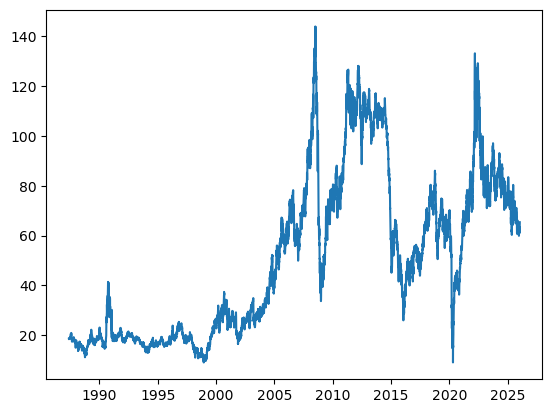

In [6]:
data['Date'] = pd.to_datetime(data['Date'])

# 绘制原始图像
plt.plot(data['Date'], data['Price'])

In [8]:
from copy import deepcopy as dc # 创建数据的深拷贝（完全独立的副本），修改副本不会影响原数据

def prepare_dataframe_for_lstm(df, n_steps):
    # 定义函数，接收两个参数：
    # df：输入的数据框
    # n_steps：回望窗口大小（用于创建历史数据列）

    df = dc(df) # 创建数据框的深拷贝，避免修改原始数据

    df.set_index('Date', inplace=True) # 将 'Date' 列设置为数据框的索引, inplace=True：直接修改原数据框，不返回新数据框, 

    # 创建时间滞后列
    for i in range(1, n_steps+1):
        df[f'Price(t-{i})'] = df['Price'].shift(i) # shift(i)：将数据向下移动i行，创建历史数据列

    df.dropna(inplace=True) # 删除包含任何NaN值的行（前n_steps行会因为shift操作产生NaN值，需要删除）

    return df

lookback = 7 # 设置回望窗口为7天
shifted_df = prepare_dataframe_for_lstm(data, lookback)
shifted_df

,Price,Price(t-1),Price(t-2),Price(t-3),Price(t-4),Price(t-5),Price(t-6),Price(t-7)
Date,,,,,,,,
1987-05-29,18.58,18.60,18.60,18.63,18.60,18.55,18.45,18.63
1987-06-01,18.65,18.58,18.60,18.60,18.63,18.60,18.55,18.45
1987-06-02,18.68,18.65,18.58,18.60,18.60,18.63,18.60,18.55
1987-06-03,18.75,18.68,18.65,18.58,18.60,18.60,18.63,18.60
1987-06-04,18.78,18.75,18.68,18.65,18.58,18.60,18.60,18.63
...,...,...,...,...,...,...,...,...
2026-01-06,62.10,63.00,61.98,61.35,62.30,63.10,63.70,63.70
2026-01-07,61.08,62.10,63.00,61.98,61.35,62.30,63.10,63.70
2026-01-08,63.34,61.08,62.10,63.00,61.98,61.35,62.30,63.10


In [10]:
# 转换为array
shifted_df_as_np = shifted_df.to_numpy()
shifted_df_as_np

array([[18.58, 18.6 , 18.6 , ..., 18.55, 18.45, 18.63],
       [18.65, 18.58, 18.6 , ..., 18.6 , 18.55, 18.45],
       [18.68, 18.65, 18.58, ..., 18.63, 18.6 , 18.55],
       ...,
       [63.34, 61.08, 62.1 , ..., 61.35, 62.3 , 63.1 ],
       [65.11, 63.34, 61.08, ..., 61.98, 61.35, 62.3 ],
       [65.4 , 65.11, 63.34, ..., 63.  , 61.98, 61.35]])

In [11]:
shifted_df_as_np.shape

(9799, 8)

In [12]:
from sklearn.preprocessing import MinMaxScaler
# 从 scikit-learn 的预处理模块导入最小-最大缩放器，用于把数值特征线性缩放到给定范围

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)

shifted_df_as_np

array([[-0.85939933, -0.85910271, -0.85910271, ..., -0.85984427,
        -0.8613274 , -0.85865777],
       [-0.85836114, -0.85939933, -0.85910271, ..., -0.85910271,
        -0.85984427, -0.8613274 ],
       [-0.8579162 , -0.85836114, -0.85939933, ..., -0.85865777,
        -0.85910271, -0.85984427],
       ...,
       [-0.19555061, -0.22906934, -0.21394142, ..., -0.22506489,
        -0.21097516, -0.19911012],
       [-0.16929922, -0.19555061, -0.22906934, ..., -0.21572117,
        -0.22506489, -0.21097516],
       [-0.16499815, -0.16929922, -0.19555061, ..., -0.20059325,
        -0.21572117, -0.22506489]])

In [13]:
X = shifted_df_as_np[:, 1:] # 取所有行、第2列到最后一列，作为特征矩阵 X（剔除第1列）。
y = shifted_df_as_np[:, 0] # 取所有行、第1列，作为目标向量 y（通常是当前时刻的 Price）。

X.shape, y.shape

((9799, 7), (9799,))

In [14]:
# 分开训练集与测试集：95%为训练集，5%为测试集
split_index = int(len(X) * 0.95)

split_index

9309

## 训练LSTM

In [15]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9309, 7), (490, 7), (9309,), (490,))

In [16]:
X_train = X_train.reshape((-1, lookback, 1)) # 把特征重塑为三维 [样本数, 时间步lookback, 特征数1]，符合 LSTM 期望的输入形状。
X_test = X_test.reshape((-1, lookback, 1)) 

y_train = y_train.reshape((-1, 1)) # 将标签改为二维列向量 [样本数, 1]，便于与模型输出对齐。
y_test = y_test.reshape((-1, 1))

# 转换为张量形式
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([9309, 7, 1]),
 torch.Size([490, 7, 1]),
 torch.Size([9309, 1]),
 torch.Size([490, 1]))

In [13]:
from torch.utils.data import Dataset

class EuropeBrentSpotPriceFOB(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EuropeBrentSpotPriceFOB(X_train, y_train)
test_dataset = EuropeBrentSpotPriceFOB(X_test, y_test)

In [14]:
train_dataset

In [15]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [17]:
learning_rate = 0.001
num_epochs = 10
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch 100, Loss: 0.421
Batch 200, Loss: 0.152
Batch 300, Loss: 0.029
Batch 400, Loss: 0.016
Batch 500, Loss: 0.011

Val Loss: 0.005
***************************************************

Epoch: 2
Batch 100, Loss: 0.007
Batch 200, Loss: 0.006
Batch 300, Loss: 0.004
Batch 400, Loss: 0.003
Batch 500, Loss: 0.003

Val Loss: 0.003
***************************************************

Epoch: 3
Batch 100, Loss: 0.003
Batch 200, Loss: 0.002
Batch 300, Loss: 0.002
Batch 400, Loss: 0.002
Batch 500, Loss: 0.002

Val Loss: 0.002
***************************************************

Epoch: 4
Batch 100, Loss: 0.001
Batch 200, Loss: 0.002
Batch 300, Loss: 0.001
Batch 400, Loss: 0.001
Batch 500, Loss: 0.002

Val Loss: 0.001
***************************************************

Epoch: 5
Batch 100, Loss: 0.001
Batch 200, Loss: 0.001
Batch 300, Loss: 0.001
Batch 400, Loss: 0.001
Batch 500, Loss: 0.001

Val Loss: 0.001
***************************************************

Epoch: 6
Batch 100, Loss: 0.00

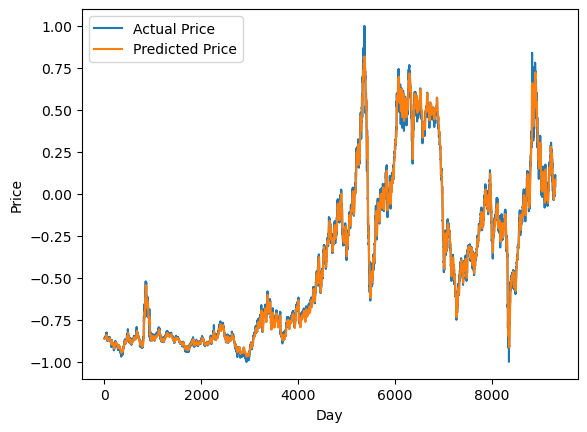

In [18]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()

plt.plot(y_train, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.legend()
plt.show()

In [19]:
train_predictions = predicted.flatten()

dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = train_predictions
dummies = scaler.inverse_transform(dummies)

train_predictions = dc(dummies[:, 0])
train_predictions

array([18.3109635 , 18.30690849, 18.33034638, ..., 82.28429112,
       82.41712042, 82.36233806])

In [20]:
dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = y_train.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_train = dc(dummies[:, 0])
new_y_train

array([18.58000094, 18.65000115, 18.68000181, ..., 82.9800001 ,
       82.19999991, 79.53999995])

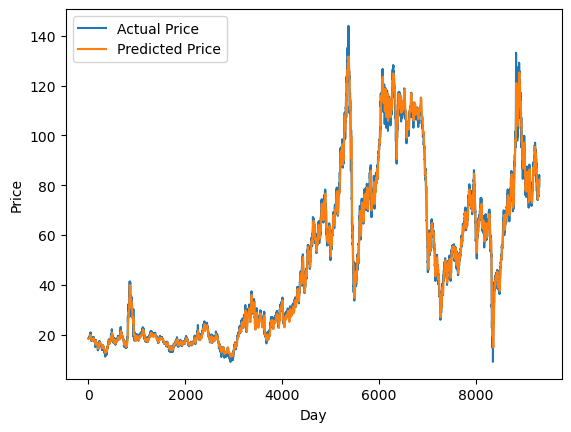

In [21]:
plt.plot(new_y_train, label='Actual Price')
plt.plot(train_predictions, label='Predicted Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.legend()
plt.show()

## 测试

In [22]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = dc(dummies[:, 0])
test_predictions

array([81.81814048, 81.28956163, 80.91602673, 80.6196255 , 80.61865093,
       80.83021489, 81.10607079, 81.84810347, 82.54306946, 83.0472464 ,
       83.57496974, 83.96039739, 84.10891877, 84.2275942 , 84.42207958,
       84.32993052, 84.24056853, 84.06805115, 83.86187194, 83.85628725,
       83.91978196, 84.11608386, 84.36287549, 84.75146397, 84.83079342,
       84.7812009 , 84.52683525, 84.35322575, 83.99159366, 84.18336432,
       84.05348686, 84.33881016, 84.82331436, 85.09757026, 85.17846957,
       85.27648313, 85.30414081, 85.40162991, 85.17966217, 85.04596731,
       85.38606895, 86.35518284, 87.22531664, 88.30549226, 89.12406029,
       90.14975748, 90.88443818, 91.44900628, 91.8492077 , 91.90255282,
       91.64785663, 91.25297816, 90.59413604, 89.9921053 , 89.36880482,
       88.67959532, 88.50156057, 88.03825627, 88.16481366, 88.15209101,
       88.14056597, 87.36889684, 86.8023354 , 85.93138779, 85.1276091 ,
       84.04479109, 83.4009277 , 82.73245744, 82.71075167, 82.08

In [23]:
dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = y_test.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_test = dc(dummies[:, 0])
new_y_test

array([79.29999991, 80.46000006, 81.17999993, 83.00999976, 83.57999982,
       83.87999993, 84.71999995, 84.40999995, 84.32999985, 84.88000014,
       85.51999991, 84.77999977, 84.76999988, 85.8400003 , 84.18000004,
       84.00999996, 83.79999984, 84.08000017, 84.57000014, 84.81999982,
       86.57999994, 85.81999952, 86.58999982, 84.88000014, 84.2899998 ,
       83.4399999 , 83.65999992, 83.95000014, 86.15999968, 85.39000038,
       86.47000018, 87.36000013, 85.77000009, 84.92000019, 84.86999975,
       86.18000046, 85.9099995 , 84.93999996, 86.16999957, 87.63000008,
       90.59999953, 90.3199997 , 92.80999957, 91.72999977, 92.13000026,
       91.56999958, 91.49000049, 93.12000008, 90.83999983, 91.28999974,
       89.53999951, 88.34000006, 87.96000035, 87.29999981, 88.28999962,
       89.02000038, 88.09999977, 89.94999988, 88.43999993, 88.2300003 ,
       83.55000016, 84.80999993, 83.6000001 , 82.68999987, 82.4400002 ,
       83.26999982, 83.38999997, 83.17999984, 80.99999996, 79.97

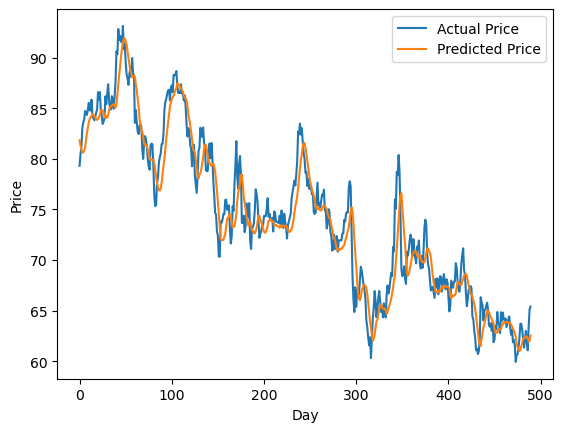

In [24]:
plt.plot(new_y_test, label='Actual Price')
plt.plot(test_predictions, label='Predicted Price')
plt.xlabel('Day')
plt.ylabel('Price')
plt.legend()
plt.show()